# Pandas數據分析

今天介紹資料分析近來很紅的 pandas 套件, 作者是 Wes McKinney。Python 會成為一個數據分析的熱門語言, 和 pandas 的出現也有相當的關係。

但是 pandas 雖然功能強, 但有些地方沒那麼直覺, 有時會讓大家以為是個深奧的套件。其實你大約可以把 pandas 想成「Python 的 Excel」, 但是功能更強、更有彈性、也有更多的可能性。

下面介紹個基本上就是把 pandas 當 Excel 學的影片, 相信大家會覺得很親切。<br>
https://youtu.be/9d5-Ti6onew

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1 開始使用 `pandas`

首先我們來讀入一個 CSV 檔, 這裡有個「假的」學測成績, 叫 `grades.csv` 我們來練習一下。

In [2]:
df = pd.read_csv('data/grades.csv')
df

,姓名,國文,英文,數學,自然,社會
0,劉俊安,9,10,15,10,13
1,胡玉華,10,10,10,8,9
2,黃淑婷,13,15,8,11,14
3,陳上紫,10,10,8,9,14
4,崔靜成,13,12,14,12,13
...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14
96,吳筱婷,8,10,14,10,15
97,陳家銘,14,9,11,8,12
98,李明威,15,9,8,9,15


用 `df` 是標準的叫法 (雖然這名稱我們隨便取也可以), 意思是 Data Frame, 這是 `pandas` 兩大資料結構之一。我們可以把 Data Frame 想成一張表格 (雖然其實可以是很多張表格)。

我們來看看我們 `df` 的前五筆資料。

In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.head()

,姓名,國文,英文,數學,自然,社會
0,劉俊安,9,10,15,10,13
1,胡玉華,10,10,10,8,9
2,黃淑婷,13,15,8,11,14
3,陳上紫,10,10,8,9,14
4,崔靜成,13,12,14,12,13


如果你曾經手動讀入 CSV 檔, 就知道這省了多少事 (雖然我個人還挺喜歡純手動帶進 CSV)。

#### Excel 檔也可以快速讀入

不只 CSV 檔, 很多資料檔案, 像 Excel 檔都很容易在 `pandas` 完成。使用法是這樣:

    df2 = pd.read_excel('filename.xls', 'sheetname')
    
其中 sheetname 那裡要放工作表的名稱, 如果是中文的最好改成英文。

## 2 Pandas 基本資料結構

Pandas 有兩個基本資料結構:

* <b style="color:red;">DataFrame</b>: 可以想成一個表格。
* <b style="color:red;">Series</b>: 表格的某一列、某一行, 基本上就是我們以前的 list 或 array

一個 DataFrame, 我們有 `index` (列的名稱), `columns` (行的名稱)。

#### DataFrame

![DataFrame 的結構](images/indexcol.png)

#### Series

剛剛說 series 大概就是一個 list, 一個 array。其實更精準的說, 其實是一個有 "index" 的 array。

DataFrame 的每一行或每一列其實也都是一個 series。我們來看個例子, 例如所有同學的國文成績, 就是一個 series。

In [7]:
df['國文']

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

在 Python 3 中, 我們終於可以和英文同步, 用這種很炫的方式叫出所有國文成績。

#### 資料畫出來

要畫個圖很容易。

<Axes: >

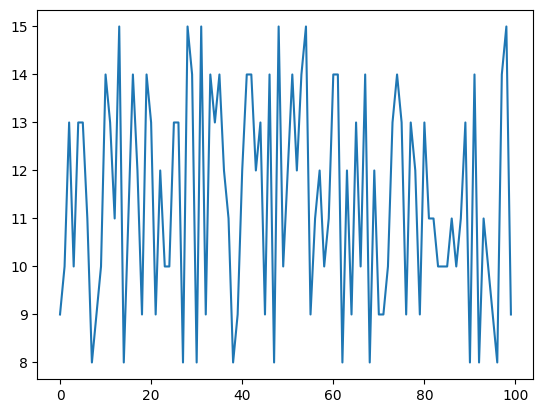

In [13]:
dataCh = pd.DataFrame()
dataCh['國文'] = df['國文']
dataCh['國文'].plot(kind = 'line')

當然, 在這個例子中, 其實畫 histogram 圖更有意義一點。

<Axes: ylabel='Frequency'>

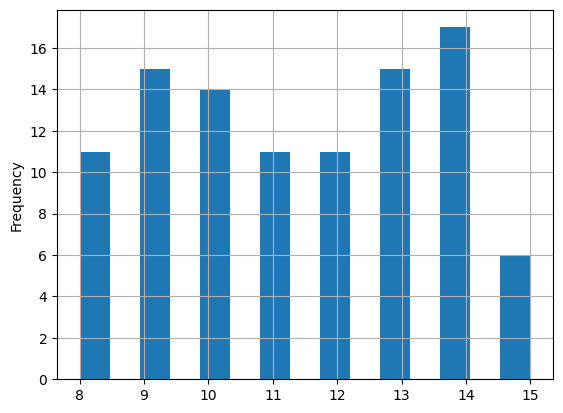

In [39]:
dataCh01 = pd.DataFrame()
dataCh01['國文'] = df['國文']
dataCh01['國文'].plot(kind='hist', bins=15, grid=True)

## 3 一些基本的資料分析

算平均。

In [41]:
print(df['國文'].mean())

11.39


算標準差。

In [43]:
print(df['國文'].std())

2.196852661459484


不如就該算的都幫我們算算...

有時我們很愛看的相關係數矩陣。

In [47]:
df.corr(numeric_only=True)

,國文,英文,數學,自然,社會
國文,1.000000,0.160158,-0.310899,-0.110236,-0.028421
英文,0.160158,1.000000,0.025656,0.113929,-0.063512
數學,-0.310899,0.025656,1.000000,0.014371,0.041651
自然,-0.110236,0.113929,0.014371,1.000000,-0.156594
社會,-0.028421,-0.063512,0.041651,-0.156594,1.000000


只算兩科間的相關係數當然也可以。

In [51]:
print(df.corr(numeric_only=True)['國文']['數學'])

-0.310898982217933


## 4 增加一行

### 【技巧】

我們增加一行, 加入總級分。

In [71]:
df.loc[:,"加權"] = df['國文']*1 + df['英文']*1 + df['數學']*2
df["總級分"] =df.loc[:, "國文":"加權"].sum(axis=1, numeric_only=True)
df.head(5)

,姓名,國文,英文,數學,自然,社會,加權,總級分
0,劉俊安,9,10,15,10,13,49,106
1,胡玉華,10,10,10,8,9,40,87
2,黃淑婷,13,15,8,11,14,44,105
3,陳上紫,10,10,8,9,14,36,87
4,崔靜成,13,12,14,12,13,53,117


### 【技巧】

有計算的當然也可以的。

In [105]:
df1 = df.drop(["總級分"],axis= 1)

In [106]:
df1

,姓名,國文,英文,數學,自然,社會,加權
0,劉俊安,9,10,15,10,13,49
1,胡玉華,10,10,10,8,9,40
2,黃淑婷,13,15,8,11,14,44
3,陳上紫,10,10,8,9,14,36
4,崔靜成,13,12,14,12,13,53
...,...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14,37
96,吳筱婷,8,10,14,10,15,46
97,陳家銘,14,9,11,8,12,45
98,李明威,15,9,8,9,15,40


In [107]:
df1["總級分"] =df1.loc[:, "國文":"社會"].sum(axis=1, numeric_only=True)
df1.loc[:,"加權"] = df1['國文']*1 + df1['英文']*1 + df1['數學']*2
df1.head(5)

,姓名,國文,英文,數學,自然,社會,加權,總級分
0,劉俊安,9,10,15,10,13,49,57
1,胡玉華,10,10,10,8,9,40,47
2,黃淑婷,13,15,8,11,14,44,61
3,陳上紫,10,10,8,9,14,36,51
4,崔靜成,13,12,14,12,13,53,64


## 5 排序和 index 重設

### 【重點】排序的方法

我們依總級分來排序。

In [110]:
df2 = df1.sort_values("總級分", ascending = False)
df2.head(11)

,姓名,國文,英文,數學,自然,社會,加權,總級分
12,李正偉,11,15,11,14,15,48,66
80,施雅鈴,13,15,12,13,13,52,66
37,曾怡君,11,12,15,13,14,53,65
25,蔡亦瑄,13,13,14,13,12,54,65
54,陳怡潔,15,15,9,15,11,48,65
83,李士賢,10,14,15,13,13,54,65
87,趙偉希,10,13,14,13,15,51,65
64,俞志峰,9,14,13,14,15,49,65
48,陳怡婷,15,14,12,9,15,53,65
57,胡淳茜,12,15,14,13,11,55,65


### 【重點】排序的方法

加權分最高, 同分才看總級分

In [129]:
df3 = df1.sort_values(['總級分', '加權'], ascending = False)
df3.head(11)

,姓名,國文,英文,數學,自然,社會,加權,總級分
80,施雅鈴,13,15,12,13,13,52,66
12,李正偉,11,15,11,14,15,48,66
57,胡淳茜,12,15,14,13,11,55,65
25,蔡亦瑄,13,13,14,13,12,54,65
83,李士賢,10,14,15,13,13,54,65
37,曾怡君,11,12,15,13,14,53,65
48,陳怡婷,15,14,12,9,15,53,65
87,趙偉希,10,13,14,13,15,51,65
64,俞志峰,9,14,13,14,15,49,65
54,陳怡潔,15,15,9,15,11,48,65


### 【重點】重設 index

In [156]:
df4 = df1.sort_values(by=['加權', '總級分'], ascending=False).reset_index(drop=True)
df4.index = df4.index + 1

In [157]:
df4

,姓名,國文,英文,數學,自然,社會,加權,總級分
1,吳志遠,13,15,15,8,8,58,59
2,胡淳茜,12,15,14,13,11,55,65
3,詹威德,12,13,15,10,14,55,64
4,蔡亦瑄,13,13,14,13,12,54,65
5,李士賢,10,14,15,13,13,54,65
...,...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36,51
97,胡凱琳,10,8,9,9,15,36,51
98,林建亨,9,11,8,8,11,36,47
99,梁慧君,9,8,8,8,12,33,45


## 6 篩出我們要的資料

基本上和 NumPy 的 array 篩法很像。

### 【重點】

找出數學滿級分同學。

In [117]:
df1[(df1.數學 == 15)]

,姓名,國文,英文,數學,自然,社會,加權,總級分
0,劉俊安,9,10,15,10,13,49,57
24,陳竹伯,10,12,15,10,14,52,61
36,詹威德,12,13,15,10,14,55,64
37,曾怡君,11,12,15,13,14,53,65
39,段冠廷,9,8,15,12,15,47,59
59,芮秋辛,11,10,15,10,8,51,54
67,林哲法,14,9,15,10,14,53,62
70,葉儀依,9,13,15,8,14,52,59
73,吳志遠,13,15,15,8,8,58,59
76,周育霖,9,12,15,13,12,51,61


### 【重點】

找出數學和英文都滿級分的同學。要注意 `and` 要用 `&`, `or` 要用 `|`。每個條件一定要加弧號。

In [118]:
df1[(df1.數學 == 15) & (df1.英文 == 15)]

,姓名,國文,英文,數學,自然,社會,加權,總級分
73,吳志遠,13,15,15,8,8,58,59


## 7 刪除一行或一列

### 【重點】刪掉一行

我們來刪掉總級分的那行。

In [119]:
df4.drop(['總級分'], axis = 1)

,姓名,國文,英文,數學,自然,社會,加權
0,吳志遠,13,15,15,8,8,58
1,胡淳茜,12,15,14,13,11,55
2,詹威德,12,13,15,10,14,55
3,蔡亦瑄,13,13,14,13,12,54
4,李士賢,10,14,15,13,13,54
...,...,...,...,...,...,...,...
95,陳上紫,10,10,8,9,14,36
96,胡凱琳,10,8,9,9,15,36
97,林建亨,9,11,8,8,11,36
98,梁慧君,9,8,8,8,12,33


### 【重點】改變原有的 DataFrame

我們會發現 `pandas` 很多動作都沒有更改原有的 DataFrame, 真的要改要加入

    inplace=True

In [134]:
df1.drop(['總級分'], axis = 1,inplace=True)
df1

,姓名,國文,英文,數學,自然,社會,加權
0,劉俊安,9,10,15,10,13,49
1,胡玉華,10,10,10,8,9,40
2,黃淑婷,13,15,8,11,14,44
3,陳上紫,10,10,8,9,14,36
4,崔靜成,13,12,14,12,13,53
...,...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14,37
96,吳筱婷,8,10,14,10,15,46
97,陳家銘,14,9,11,8,12,45
98,李明威,15,9,8,9,15,40


### 【重點】刪掉一列

刪掉列就是指定要刪去的 index。

In [154]:
df4 = df4.drop(4)
df4

,姓名,國文,英文,數學,自然,社會,加權,總級分
1,吳志遠,13,15,15,8,8,58,59
2,胡淳茜,12,15,14,13,11,55,65
3,詹威德,12,13,15,10,14,55,64
6,童心怡,13,13,14,8,13,54,61
7,曾怡君,11,12,15,13,14,53,65
...,...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36,51
97,胡凱琳,10,8,9,9,15,36,51
98,林建亨,9,11,8,8,11,36,47
99,梁慧君,9,8,8,8,12,33,45


In [155]:
df4.head(5)

,姓名,國文,英文,數學,自然,社會,加權,總級分
1,吳志遠,13,15,15,8,8,58,59
2,胡淳茜,12,15,14,13,11,55,65
3,詹威德,12,13,15,10,14,55,64
6,童心怡,13,13,14,8,13,54,61
7,曾怡君,11,12,15,13,14,53,65


### 【重點】刪掉一列

通常刪掉符合條件的比較合理 (注意是找到要刪掉的部份, 再找出相對的 index)。

In [158]:
df4.drop(df4[df4.姓名 == '李士賢'].index, inplace=True)

In [159]:
df4

,姓名,國文,英文,數學,自然,社會,加權,總級分
1,吳志遠,13,15,15,8,8,58,59
2,胡淳茜,12,15,14,13,11,55,65
3,詹威德,12,13,15,10,14,55,64
4,蔡亦瑄,13,13,14,13,12,54,65
6,童心怡,13,13,14,8,13,54,61
...,...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36,51
97,胡凱琳,10,8,9,9,15,36,51
98,林建亨,9,11,8,8,11,36,47
99,梁慧君,9,8,8,8,12,33,45


## 8 真實股價資料

有個從 `Pandas` 獨立出來的套件叫 `pandas-datareader`, 幾經波折, 先是 Yahoo! 的財務資料不能用, 後來又是 Google 的資料不能用, 不過至少現在看來 Yahoo! 還可以使用。

安裝 `pandas-datareader` 就標準 `conda` 安裝:

    conda install pandas-datareader
    
如果裝過, 但很久沒更新就用:

    conda update pandas-datareader

### 【例子】 分析 Apple 股價

In [5]:
!pip install pandas_datareader yfinance


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sys; print(sys.executable)

C:\Users\User\AppData\Local\Programs\Python\Python314\python.exe


In [8]:
!C:\Users\User\AppData\Local\Programs\Python\Python314\python.exe -m pip install pandas_datareader yfinance

  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-4.0.5-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
Using cached yfinance-1.3.0-py2.py3-none-any.whl (133 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached p


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [9]:
import pandas_datareader as pdr
import yfinance as yf
df = pdr.get_data_yahoo('AAPL')

RemoteDataError: Unable to read URL: https://finance.yahoo.com/quote/AAPL/history?period1=1619899200&period2=1777665599&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'>\n<script>\nif(window != window.top){\ndocument.write(\'<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t=\'\n    + new Date().getTime() + \'&_R=\'\n    + encodeURIComponent(document.referrer)\n    + \'&err=404\'\n    + \'" width="0px" height="0px"/>\');\n}else{\nwindow.location.replace(\'https://\' + window.location.host + \'/?err=404\');\n}\n</script>\n<noscript>\n<META http-equiv="refresh" content="0;URL=https://finance.yahoo.com/?err=404">\n</noscript></html>'

In [12]:
# 為防止網路有問題, 我們把這個檔案以 aapl.csv 存起來, 可以這樣讀入。
df = pd.read_csv('data/aapl.csv', index_col="Date")

In [14]:
df.tail(300)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-10-03,112.709999,113.050003,112.279999,112.519997,110.173546,21701800
2016-10-04,113.059998,114.309998,112.629997,113.000000,110.643539,29736800
2016-10-05,113.400002,113.660004,112.690002,113.050003,110.692505,21453100
2016-10-06,113.699997,114.339996,113.129997,113.889999,111.514984,28779300
2016-10-07,114.309998,114.559998,113.510002,114.059998,111.681435,24358400
...,...,...,...,...,...,...
2017-12-04,172.479996,172.619995,169.630005,169.800003,169.800003,32542400
2017-12-05,169.059998,171.520004,168.399994,169.639999,169.639999,27350200
2017-12-06,167.500000,170.199997,166.460007,169.009995,169.009995,28560000


In [17]:
df.head(20)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-12-31,30.447144,30.478571,30.080000,30.104286,26.986492,88102700
2010-01-04,30.490000,30.642857,30.340000,30.572857,27.406532,123432400
2010-01-05,30.657143,30.798571,30.464285,30.625713,27.453915,150476200
2010-01-06,30.625713,30.747143,30.107143,30.138571,27.017223,138040000
2010-01-07,30.250000,30.285715,29.864286,30.082857,26.967278,119282800
2010-01-08,30.042856,30.285715,29.865715,30.282858,27.146566,111902700
2010-01-11,30.400000,30.428572,29.778572,30.015715,26.907093,115557400
2010-01-12,29.884285,29.967142,29.488571,29.674286,26.601023,148614900
2010-01-13,29.695715,30.132856,29.157143,30.092857,26.976244,151473000


#### 只要最後 300 個交易日!

In [30]:
listRe = [] 

for i in range(len(df)):
    if i >= 19:
        twentRe = df['Adj Close'].iloc[i-19:i+1].mean()
    else:
        twentRe = None #賦予空值，避免當數值0-18未達19時被塞其他數字
    listRe.append(twentRe)
#print(listRe)    

ma_series = pd.Series(listRe, index=df.index)
print(ma_series)

Date
2009-12-31           NaN
2010-01-04           NaN
2010-01-05           NaN
2010-01-06           NaN
2010-01-07           NaN
                 ...    
2017-12-04    172.568420
2017-12-05    172.369128
2017-12-06    172.110436
2017-12-07    171.796001
2017-12-08    171.502000
Length: 2000, dtype: float64


In [ ]:
# listRe = [] 

# for date, row in df.iterrows():  
#     for i in range(len(date)):
#         twentRe = df['Adj Close'].iloc[i+19:i].mean()
#         listRe.append(twentRe)

# print(listRe)
# #這樣寫會變成for date, row in df.iterrows(): 裡面，變數 date 的內容其實是一個 Timestamp（時間物件） 或字串（例如 "2010-01-04"）。
# #當你執行 len(date) 時，如果你算的是字串 "2010-01-04" 的長度，結果會是 10。



# listRe = [] 

# for i in range(len(df)):
#     twentRe = df['Adj Close'].iloc[i+19:i].mean()
#     listRe.append(twentRe)

# print(listRe)
# 切片順序 (Start : Stop)：在 Python 中，切片必須是 [小索引 : 大索引]。你的寫法：iloc[i+19 : i]（大到小），這會抓到空的資料，導致平均值是 NaN。
# 正確寫法：iloc[i-19 : i+1]（小到大），這樣才會抓到從過去到現在的 20 筆。
# 避免「提早計算」：當 i 還很小（例如 i=0）時，i-19 會變成負數，這會導致 iloc 從 DataFrame 的尾巴開始抓資料（Python 的負索引特性），這不是我們要的。
# 建議：加一個 if i >= 19: 的判斷，天數夠了再算平均。

In [26]:
df['MA20'] = df['Adj Close'].rolling(window=20).mean()
df['MA20']

Date
2009-12-31           NaN
2010-01-04           NaN
2010-01-05           NaN
2010-01-06           NaN
2010-01-07           NaN
                 ...    
2017-12-04    172.568420
2017-12-05    172.369128
2017-12-06    172.110436
2017-12-07    171.796001
2017-12-08    171.502000
Name: MA20, Length: 2000, dtype: float64

#### 20 日的移動平均

<Axes: xlabel='Date'>

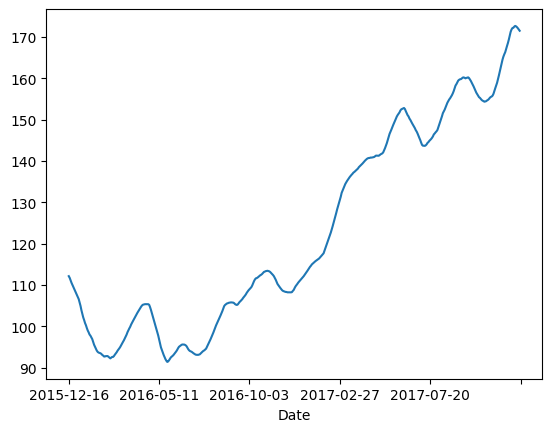

In [37]:
ma_series.tail(500).plot(kind = 'line')

<Axes: xlabel='Date'>

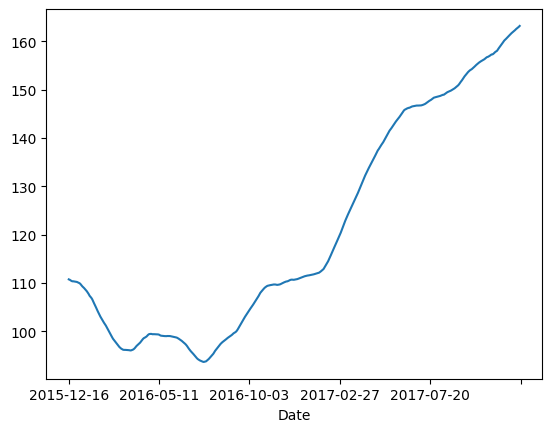

In [38]:
df['MA60'] = df['Adj Close'].rolling(window=60).mean()
df['MA60'].tail(500).plot(kind = 'line')

#### 20 日和 60 日的移動平均

<AxesSubplot:xlabel='Date'>

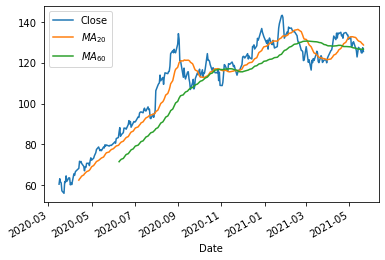

In [68]:
df.Close.plot(legend=True)
df.Close.rolling(20).mean().plot(label="$MA_{20}$",legend=True)
df.Close.rolling(60).mean().plot(label="$MA_{60}$",legend=True)

#### 準備做預測

我們用個非常天真的模型...

![天真股票模型](images/naive.png)

網路上說這是線性的 (可能嗎)!


In [ ]:
# ============================================================
# 【 預測模型：資料對齊邏輯 (X, y) 】
# 假設資料範圍：1月1日 (最久以前) 至 1月10日 (最新)
# ============================================================

# 1. 為何 y (目標) 要捨棄第一筆 (1月1日)？
#    - 預測目標 y 需要一個「因」來推算。
#    - 要預測 1月1日的股價，需要 12月31日的資料。
#    - 因為 1月1日就是資料起點，我們沒有 12月31日，所以 y 的首筆無效。
#    - 做法：y = 股價資料[1:] (從第 2 筆開始拿)

# 2. 為何 X (特徵) 要捨棄最後一筆 (1月10日)？
#    - 預測特徵 X 需要一個「果」來對應答案。
#    - 用 1月10日當特徵去預測，目標會是 1月11日。
#    - 資料庫最新只到 1月10日，並沒有 1月11日的答案可以對齊。
#    - 做法：X = 股價資料[:-1] (拿到底部前 1 筆為止)

# 3. 最終對齊結果：
#    - X (1/1, 1/2... 1/9) 剛好對應 y (1/2, 1/3... 1/10)
#    - 兩者長度一致 (都是 9 筆)，且每一組都是「今天對明天」。
# ============================================================

In [44]:
close = df.head(300).Close
print(len(close.values))

300


In [47]:
x = close[:-1:].copy()
print(len(x))

299


In [49]:
y = close[1::].copy()
print(len(y))

299


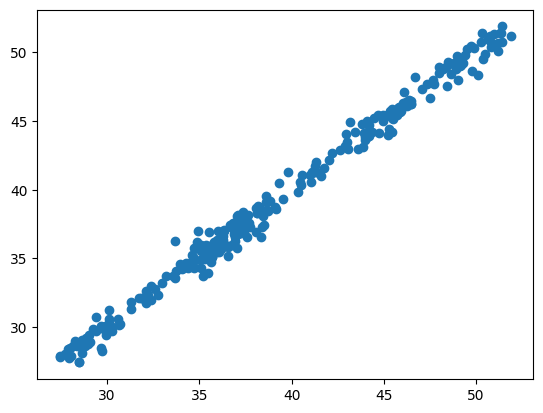

In [50]:
import matplotlib.pyplot as plt
plt.scatter(x, y) 

哦, 真的有點像線性的, 我們之後用線性迴歸試試看。

## 9 手工打造一個 DataFrame*

有時我們用手工打造一個簡單的 DataFrame, 可以更理解整個結構。其實很容易, 一個 DataFrame 基本上就包含兩個主要部份:

* 資料本身: 通常一個二維陣列 (矩陣)
* 行、列的名稱

我們來個簡單的小例子。

In [52]:
mydata = np.random.randn(4,3)

In [53]:
mydata

array([[ 1.52721845,  0.48688969,  0.22001396],
       [-0.59976509,  0.79040175, -1.54228743],
       [ 0.79565754, -0.04256432, -1.98039651],
       [-0.34174231,  0.99155008, -0.27094983]])

把行列的名字放進去, 就成一個 DataFrame。我們列的部份先讓 Python 自己產生。

In [54]:
df2 = pd.DataFrame(mydata, columns=list("ABC"))

In [55]:
df2

,A,B,C
0,1.527218,0.486890,0.220014
1,-0.599765,0.790402,-1.542287
2,0.795658,-0.042564,-1.980397
3,-0.341742,0.991550,-0.270950


#### 兩個表格上下貼起來

我們再來生一個 DataFrame, 再「貼」起來。

In [57]:
df3 = pd.DataFrame(np.random.randn(3,3), columns=list("ABC"))

In [58]:
df3

,A,B,C
0,-0.754272,-2.397026,0.360023
1,0.758392,-0.345077,-0.423378
2,0.454266,-0.265281,-0.925155


In [60]:
df4 = pd.concat([df2, df3], axis=0)

In [61]:
df4

,A,B,C
0,1.527218,0.486890,0.220014
1,-0.599765,0.790402,-1.542287
2,0.795658,-0.042564,-1.980397
3,-0.341742,0.991550,-0.270950
0,-0.754272,-2.397026,0.360023
1,0.758392,-0.345077,-0.423378
2,0.454266,-0.265281,-0.925155


前面我們弄得亂七八糟的 index 重設一下。

In [64]:
df4_new = df4.reset_index(drop=True)

In [65]:
df4_new

,A,B,C
0,1.527218,0.486890,0.220014
1,-0.599765,0.790402,-1.542287
2,0.795658,-0.042564,-1.980397
3,-0.341742,0.991550,-0.270950
4,-0.754272,-2.397026,0.360023
5,0.758392,-0.345077,-0.423378
6,0.454266,-0.265281,-0.925155


#### 横向的貼

In [67]:
df4_trans = df4_new.T

等等, 這大小好像不太對也可以嗎? 答案是可以的!

In [70]:
df4_trans

,0,1,2,3,4,5,6
A,1.527218,-0.599765,0.795658,-0.341742,-0.754272,0.758392,0.454266
B,0.486890,0.790402,-0.042564,0.991550,-2.397026,-0.345077,-0.265281
C,0.220014,-1.542287,-1.980397,-0.270950,0.360023,-0.423378,-0.925155


#### 大一點的例子

我們來做前面「假的」學測資料。首先要有「假的」同學名單, 如果有興趣產生很多名字, 可以用這個服務。

[中文姓名產生器](http://www.richyli.com/name/index.asp)

In [71]:
dfName = pd.read_csv('names.csv')

In [77]:
dfName = dfName.drop(['編號'], axis=1)

In [78]:
dfName

,姓名
0,李恩晴
1,許婉柔
2,李雨琳
3,張心婷
4,何雨翔
...,...
95,林彥妤
96,羅宸蓉
97,羅品毅
98,蔡宸勳


In [79]:
df_grades = pd.DataFrame(np.random.randint(6,16,(100,5)),
                        columns=['國文','英文','數學','社會','自然'])

In [80]:
df_grades

,國文,英文,數學,社會,自然
0,13,13,14,7,9
1,10,14,12,8,11
2,11,12,12,6,11
3,14,6,10,10,13
4,9,11,12,15,12
...,...,...,...,...,...
95,6,9,11,15,14
96,10,15,12,11,11
97,12,13,15,10,10
98,13,6,6,9,12


In [81]:
df_grades['Unnamed: 0'] = range(len(df_grades))

In [83]:
df_grades

,國文,英文,數學,社會,自然,Unnamed: 0
0,13,13,14,7,9,0
1,10,14,12,8,11,1
2,11,12,12,6,11,2
3,14,6,10,10,13,3
4,9,11,12,15,12,4
...,...,...,...,...,...,...
95,6,9,11,15,14,95
96,10,15,12,11,11,96
97,12,13,15,10,10,97
98,13,6,6,9,12,98


In [84]:
df_gradesN = pd.concat([dfName, df_grades], axis=1)

In [85]:
df_gradesN

,姓名,國文,英文,數學,社會,自然,Unnamed: 0
0,李恩晴,13,13,14,7,9,0
1,許婉柔,10,14,12,8,11,1
2,李雨琳,11,12,12,6,11,2
3,張心婷,14,6,10,10,13,3
4,何雨翔,9,11,12,15,12,4
...,...,...,...,...,...,...,...
95,林彥妤,6,9,11,15,14,95
96,羅宸蓉,10,15,12,11,11,96
97,羅品毅,12,13,15,10,10,97
98,蔡宸勳,13,6,6,9,12,98
